In [2]:
import numpy as np
import math
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
%matplotlib inline

In [3]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    print("No GPU available. Training will run on CPU.")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

GPU: Tesla T4 is available.
Using device: cuda


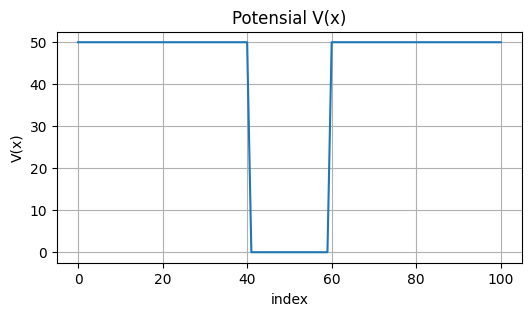

In [4]:
data = np.load('/content/kotak3_bener.npz')

potensial_dataset = data['potensial']
V_REF = potensial_dataset[0]
N_POINTS = len(V_REF)
DX = 0.1

plt.figure(figsize=(6,3))
plt.plot(V_REF*5)
plt.title('Potensial V(x)')
plt.xlabel('index'); plt.ylabel('V(x)')
plt.grid(True)
plt.show()



In [4]:
# potensial = data['potensial']
# plt.plot(potensial[0,:])

In [5]:
psi_awal  = data['psi_awal'].astype(np.float32)
psi_akhir = data['psi_akhir'].astype(np.float32)

X_raw = psi_awal
y_raw = psi_akhir
GLOBAL_SCALE = max(np.abs(X_raw).max(), np.abs(y_raw).max())

X = X_raw / GLOBAL_SCALE
y = y_raw / GLOBAL_SCALE


print("Shape X:", X.shape)
print("Shape y:", y.shape)

Shape X: (5000, 101)
Shape y: (5000, 101)


In [6]:
X = X[:,:,np.newaxis]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor,  y_test_tensor)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print("X_train:", X_train_tensor.shape)
print("X_test :", X_test_tensor.shape)

X_train: torch.Size([4000, 101, 1])
X_test : torch.Size([1000, 101, 1])


In [8]:
import torch
import torch.nn as nn
import math
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 256, dropout: float = 0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class QuantumTransformer(nn.Module):

    def __init__(
        self,
        in_features       : int   = 1,
        seq_len           : int   = 101,
        d_model           : int   = 64,
        nhead             : int   = 8,
        num_encoder_layers: int   = 4,
        dim_feedforward   : int   = 256,
        dropout           : float = 0.1,
    ):
        super().__init__()
        assert d_model % nhead == 0, \
            f"d_model ({d_model}) harus habis dibagi nhead ({nhead})"

        # a) Proyeksi input → d_model
        self.input_proj = nn.Linear(in_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len, dropout=0.2)
        # c) Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model         = d_model,
            nhead           = nhead,
            dim_feedforward = dim_feedforward,
            dropout         = dropout,
            batch_first     = True,
            activation      = 'gelu',
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer,num_layers=num_encoder_layers,)

        # d) Output head: prediksi 1 nilai per titik grid
        self.output_head = nn.Sequential(
            nn.Linear(d_model, 32),
            nn.GELU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x   = self.input_proj(x)              # (batch, 101, d_model)
        x   = self.pos_enc(x)
        x   = self.transformer_encoder(x)     # (batch, 101, d_model)
        out = self.output_head(x).squeeze(-1)             # (batch, 101)
        return out

In [9]:
import copy
import torch
import torch.nn as nn
import math


def run(
    d_model=128,
    nhead=8,
    n_layers=4,
    dim_feedforward=512,
    weight_decay=5e-5,
    warmup_steps=4000,
    n_epochs=100,
    max_norm=1.0,
):
    # MODEL
    model = QuantumTransformer(
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=n_layers,
        dim_feedforward=dim_feedforward,
        dropout=0.1,
    ).to(device)

    # OPTIMIZER sesuai spesifikasi paper: beta1=0.9, beta2=0.98, eps=1e-9
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1.0,                 # placeholder, nilai asli diatur oleh lambda scheduler
        betas=(0.9, 0.98),
        eps=1e-9,
        weight_decay=weight_decay,
    )

    criterion = nn.SmoothL1Loss()

    # LEARNING RATE SCHEDULE SESUAI RUMUS PAPER
    def transformer_lr_lambda(step_num):
        step_num = max(step_num, 1)  # hindari pembagian 0 di step ke-0
        return (d_model ** -0.5) * min(step_num ** -0.5, step_num * (warmup_steps ** -1.5))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=transformer_lr_lambda)

    train_losses = []
    test_losses  = []
    best_loss    = float("inf")
    best_model   = copy.deepcopy(model.state_dict())

    for epoch in range(n_epochs):
        # ── TRAINING ─────────────────────────────────────────
        model.train()
        total_train_loss = 0
        for X_train_batch, y_train_batch in train_loader:
            X_train_batch = X_train_batch.to(device)
            y_train_batch = y_train_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_train_batch)
            loss   = criterion(y_pred, y_train_batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_norm)
            optimizer.step()
            scheduler.step()          # update learning rate SETIAP STEP (bukan per epoch)

            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ── TESTING ──────────────────────────────────────────
        model.eval()
        total_test_loss = 0
        with torch.no_grad():
            for X_test_batch, y_test_batch in test_loader:
                X_test_batch = X_test_batch.to(device)
                y_test_batch = y_test_batch.to(device)
                y_pred = model(X_test_batch)
                loss = criterion(y_pred, y_test_batch)
                total_test_loss += loss.item()
        avg_test_loss = total_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)

        # ── SIMPAN MODEL TERBAIK ─────────────────────────────
        if avg_test_loss < best_loss:
            best_loss  = avg_test_loss
            best_model = copy.deepcopy(model.state_dict())

        current_lr = optimizer.param_groups[0]['lr']

    model.load_state_dict(best_model)
    return best_loss, model, train_losses, test_losses

In [10]:
least_val_loss     = float("inf")
least_loss_model   = None
best_train_losses  = None
best_test_losses   = None
best_hyperparams   = None

d_model_list       = [32, 64]
n_head_list        = [2, 4]
n_layers_list      = [2,3]
weight_decay_list  = [5e-5]
warmup_steps_list  = [4000]
d_ffn_list         = [256]

total = (
    len(d_model_list)
    * len(n_head_list)
    * len(n_layers_list)
    * len(weight_decay_list)
    * len(warmup_steps_list)
)
print(f"→ Total kombinasi: {total} hyperparameter\n")

counter = 0
for d_model in d_model_list:
    for n_head in n_head_list:
        for n_layers in n_layers_list:
            for weight_decay in weight_decay_list:
                for warmup_steps in warmup_steps_list:
                    counter += 1
                    print(
                        f"[{counter}/{total}] "
                        f"d_model={d_model}, "
                        f"n_head={n_head}, "
                        f"n_layers={n_layers}, "
                        f"d_ff={d_model*2}, "
                        f"warmup_steps={warmup_steps}"
                    )
                    val_loss, model, train_losses, test_losses = run(
                        d_model=d_model,
                        nhead=n_head,
                        n_layers=n_layers,
                        weight_decay=weight_decay,
                        warmup_steps=warmup_steps,
                        dim_feedforward=d_model * 2,
                        n_epochs=100,
                    )

                    # ── TAMPILKAN VALIDATION LOSS SETIAP KOMBINASI ──
                    print(f"    Validation Loss = {val_loss:.10f}")

                    if val_loss < least_val_loss:
                        least_val_loss    = val_loss
                        least_loss_model  = model
                        best_train_losses = train_losses
                        best_test_losses  = test_losses
                        best_hyperparams  = {
                            "d_model": d_model,
                            "n_head": n_head,
                            "n_layers": n_layers,
                            "weight_decay": weight_decay,
                            "warmup_steps": warmup_steps,
                            "dim_feedforward": d_model * 2,
                        }
                        print("    ===== NEW BEST MODEL =====")
                        print(f"    {best_hyperparams}")
                        print(f"    Best so far: {least_val_loss:.10f}\n")
                    else:
                        print()  # spasi biar rapi antar kombinasi

print("\n========== GRID SEARCH FINISHED ==========")
print("Best Hyperparameters:")
print(best_hyperparams)
print(f"Best Validation Loss = {least_val_loss:.10f}")

→ Total kombinasi: 8 hyperparameter

[1/8] d_model=32, n_head=2, n_layers=2, d_ff=64, warmup_steps=4000
    Validation Loss = 0.0000000941
    ===== NEW BEST MODEL =====
    {'d_model': 32, 'n_head': 2, 'n_layers': 2, 'weight_decay': 5e-05, 'warmup_steps': 4000, 'dim_feedforward': 64}
    Best so far: 0.0000000941

[2/8] d_model=32, n_head=2, n_layers=3, d_ff=64, warmup_steps=4000
    Validation Loss = 0.0000000550
    ===== NEW BEST MODEL =====
    {'d_model': 32, 'n_head': 2, 'n_layers': 3, 'weight_decay': 5e-05, 'warmup_steps': 4000, 'dim_feedforward': 64}
    Best so far: 0.0000000550

[3/8] d_model=32, n_head=4, n_layers=2, d_ff=64, warmup_steps=4000
    Validation Loss = 0.0000000520
    ===== NEW BEST MODEL =====
    {'d_model': 32, 'n_head': 4, 'n_layers': 2, 'weight_decay': 5e-05, 'warmup_steps': 4000, 'dim_feedforward': 64}
    Best so far: 0.0000000520

[4/8] d_model=32, n_head=4, n_layers=3, d_ff=64, warmup_steps=4000
    Validation Loss = 0.0000000967

[5/8] d_model=64, n_

In [12]:
from sklearn.metrics import mean_squared_error
import time

model.eval()
if device.type == 'cuda':
    torch.cuda.synchronize()
start = time.time()
X_test_list, y_true_list, y_pred_list = [], [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        X_test_list.append(X_batch.cpu())
        y_true_list.append(y_batch.cpu())
        y_pred_list.append(y_pred.cpu())

X_test_all = torch.cat(X_test_list)
y_true_all = torch.cat(y_true_list)
y_pred_all = torch.cat(y_pred_list)

# kembali ke skala fisis asli
y_pred_denorm = y_pred_all * GLOBAL_SCALE
y_true_denorm = y_true_all * GLOBAL_SCALE

if device.type == 'cuda':
    torch.cuda.synchronize()
print(f"Inference time: {time.time() - start:.4f}s")

print("X_test_all   :", X_test_all.shape)
print("y_true_denorm:", y_true_denorm.shape)
print("y_pred_denorm:", y_pred_denorm.shape)

Inference time: 0.0807s
X_test_all   : torch.Size([1000, 101, 1])
y_true_denorm: torch.Size([1000, 101])
y_pred_denorm: torch.Size([1000, 101])


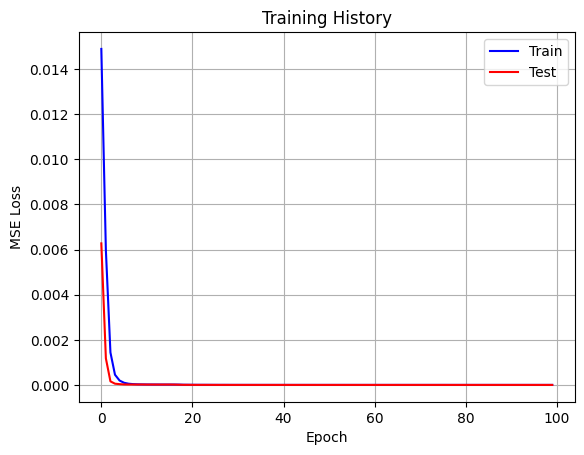

In [13]:
plt.plot(best_train_losses, label='Train', color='blue')
plt.plot(best_test_losses, label='Test', color='red')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)
plt.show()

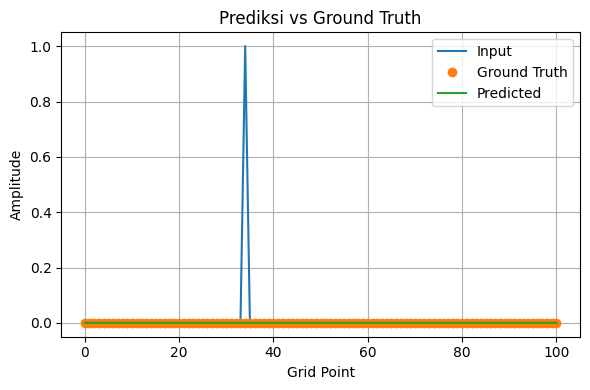

In [14]:

# Pastikan tensor dalam bentuk CPU dan NumPy sebelum plot
x_input = X_test_all[0, :].cpu().detach().numpy()
y_true = y_true_all[0, :].cpu().detach().numpy()
y_pred = y_pred_all[0, :].cpu().detach().numpy()
plt.figure(figsize=(6, 4))
plt.plot(x_input, label='Input')
plt.plot(y_true, 'o', label='Ground Truth')
plt.plot(y_pred, label='Predicted')
plt.title("Prediksi vs Ground Truth")
plt.xlabel("Grid Point")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("test-model1.png", dpi=300)
plt.show()

In [15]:
def normalisasi(X, dx = 0.1):
    X_np = X.detach().cpu().numpy()
    X = X_np.copy()
    for n in range(X.shape[0]):
        psi = X[n, :]
        sum_psi = np.sum(psi[1:]**2) #dari indeks 1
        A = 1 / np.sqrt(sum_psi * dx)
        X[n, :] = psi * A
    return torch.tensor(X, dtype=torch.float32)

def koma_formatter(x, pos):
    """Format angka desimal: titik → koma."""
    return f"{x:.2f}".replace('.', ',')

In [16]:
def normalisasi(X, dx = 0.1):
    X_np = X.detach().cpu().numpy()
    X = X_np.copy()
    for n in range(X.shape[0]):
        psi = X[n, :]
        sum_psi = np.sum(psi[1:]**2) #dari indeks 1
        A = 1 / np.sqrt(sum_psi * dx)
        X[n, :] = psi * A
    return torch.tensor(X, dtype=torch.float32)

def koma_formatter(x, pos):
    """Format angka desimal: titik → koma."""
    return f"{x:.2f}".replace('.', ',')

In [17]:
def prediksi(X, model, dx=0.1, tol=1e-7, max_iter=10000, simpan_dir='hasil'):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.ticker import FuncFormatter
    import torch

    os.makedirs(simpan_dir, exist_ok=True)

    # Device mengikuti model
    device = next(model.parameters()).device
    X_normalisasi = normalisasi(X, dx).to(device)

    # Pastikan bentuk input (batch, Nx, 1)
    if X_normalisasi.ndim == 2:
        X_normalisasi = X_normalisasi.unsqueeze(-1)

    current_input = X_normalisasi.clone().detach()
    history = []

    for iterasi in range(max_iter):
        with torch.no_grad():
            result = model(current_input)

        # Hilangkan channel terakhir jika ada
        if result.ndim == 3:
            result = result.squeeze(-1)

        if current_input.ndim == 3:
            current_compare = current_input.squeeze(-1)
        else:
            current_compare = current_input

        result = normalisasi(result, dx).to(device)

        # Pastikan kedua tensor berada pada device yang sama
        current_compare = current_compare.to(device)
        diff = torch.mean(torch.abs(result - current_compare)).item()
        history.append(diff)

        print(f"Iterasi {iterasi+1}, perubahan = {diff:.6e}")
        if iterasi == 0 or diff < tol:
            x_plot = np.arange(result.shape[1])
            input_cpu = current_compare[0, :].detach().cpu().numpy()
            result_cpu = result[0, :].detach().cpu().numpy()
            Nx = len(result_cpu) - 1
            v = np.zeros(Nx + 1)
            for i in range(Nx + 1):
                if i <= 40 or i >= 60:
                    v[i] = 50.0

            fig, ax1 = plt.subplots(figsize=(6,4))
            ax1.plot(x_plot, input_cpu,'o', color='red',label=r'$\psi(x)$ Input')
            ax1.plot(x_plot, result_cpu,'-', color='blue',linewidth=2,label=r'$\psi(x)$ Output')
            ax1.set_xlabel('x')
            ax1.set_ylabel(r'$\psi(x)$')
            ax1.grid(True)
            try:
                ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))
            except:
                pass

            ax2 = ax1.twinx()
            ax2.plot(x_plot,v,'--',color='green',label='Potensial')
            ax2.set_ylabel(r'$V(x)$')
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()

            ax1.legend(lines1 + lines2,labels1 + labels2,loc='upper center',bbox_to_anchor=(0.5, -0.15),ncol=3,frameon=False)
            plt.tight_layout()
            plt.savefig(os.path.join(simpan_dir,f"iterasi_{iterasi+1}.png"),dpi=300)
            plt.show()
            plt.close()

        # Konvergen
        if diff < tol:
            print(
                f"Konvergensi tercapai pada iterasi {iterasi+1} "
                f"dengan perubahan = {diff:.2e}"
            )
            break
        current_input = result.unsqueeze(-1).detach().clone().to(device)

    return current_input.cpu(), result.cpu(), history

Iterasi 1, perubahan = 1.577870e-01


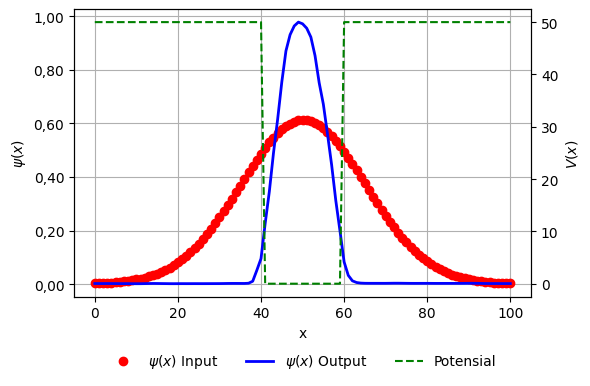

Iterasi 2, perubahan = 3.110036e-03
Iterasi 3, perubahan = 2.892410e-04
Iterasi 4, perubahan = 1.728238e-05
Iterasi 5, perubahan = 8.221008e-07
Iterasi 6, perubahan = 1.381527e-07
Iterasi 7, perubahan = 1.077187e-07
Iterasi 8, perubahan = 9.407626e-08


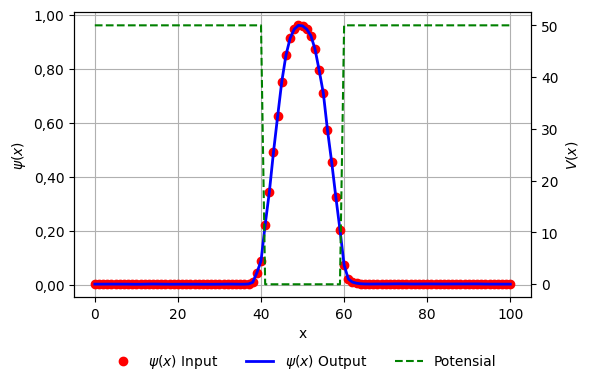

Konvergensi tercapai pada iterasi 8 dengan perubahan = 9.41e-08


In [18]:
# parameter simulasi
Nx = 100
L = 10.0
dx = L / Nx
dtau = 0.5 * dx**2
x = np.linspace(0, L, Nx + 1)

#potensial kotak
Nx = 100
v = np.zeros(Nx + 1)
for i in range(Nx + 1):
  v[i] = 50.0 if (i <= 40 or i >= 80) else 0.0

geser = np.random.uniform(-0.2, 0.2)*L
x0 = (0.5*L) + geser
sigma = 0.15*L
psi = np.exp(-((x - x0)**2) / (2*sigma**2))
psi /= np.sqrt(np.sum(psi**2) * dx) # normalisasi awal
model.eval()
psi_current = torch.tensor(
    psi,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(-1).to(device)

final_input, result, history = prediksi(psi_current, model, dx=0.1, tol=1e-7, max_iter=10000)

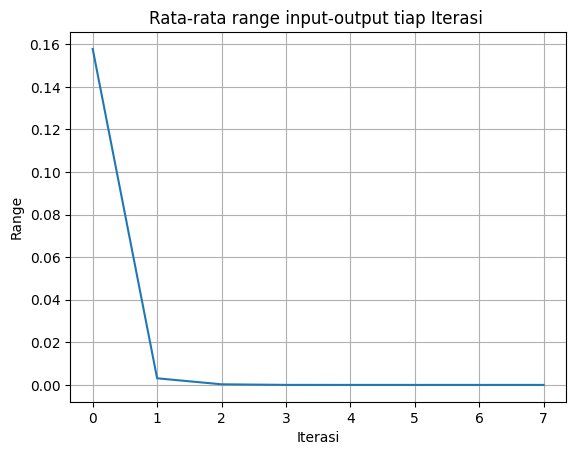

In [19]:
# Ubah semua tensor di history jadi numpy
#history_np = [h.detach().numpy() for h in history]
#plot perubahan (history)
plt.plot(history)
plt.title('Rata-rata range input-output tiap Iterasi ')
plt.xlabel('Iterasi')
plt.ylabel('Range')
plt.grid(True)
plt.show()

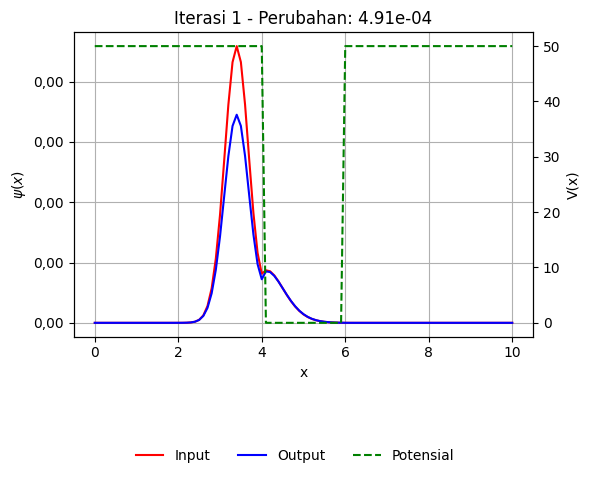

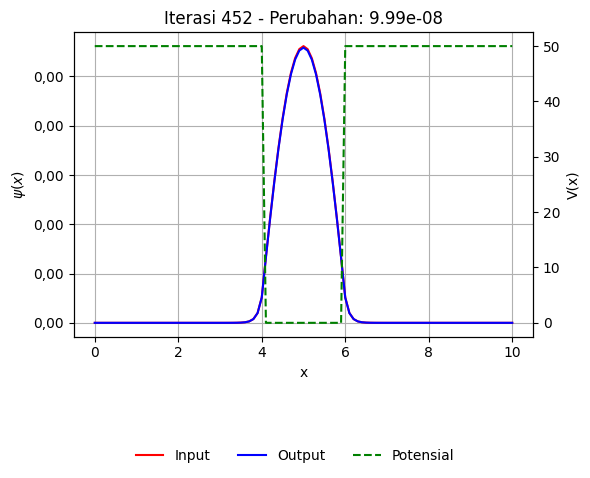

Konvergensi tercapai pada iterasi ke-452, perubahan: 9.99e-08
Waktu komputasi: 2.6437 detik (0.04 menit)
Shape psi_konvergen: (101,)


In [20]:
import time

def fdtd_iterasi_awal_dari_model(y_true_all, dx=0.1, L=10, dt=0.005, Nt=10000, tol=1e-7):
    Nx  = int(L / dx)
    x   = np.linspace(0, L, Nx + 1)
    dx2 = dx**2

    v = np.zeros(Nx + 1)
    for i in range(Nx + 1):
        v[i] = 50.0 if (i <=40 or i >= 60) else 0.0

    psi     = y_true_all[0, :].detach().cpu().numpy().copy()
    history = []

    a = (1 - 0.5 * dt * v) / (1 + 0.5 * dt * v)
    b = dt / (2 * dx2 * (1 + 0.5 * dt * v))

    waktu_mulai = time.time()  # <-- mulai stopwatch

    for iterasi in range(1, Nt + 1):
        psi_new       = np.zeros(Nx + 1)
        psi_new[1:-1] = (a[1:-1] * psi[1:-1]
                         + b[1:-1] * (psi[2:] - 2 * psi[1:-1] + psi[:-2]))
        psi_new[0] = psi_new[-1] = 0.0
        perubahan  = np.linalg.norm(psi_new - psi)
        history.append(perubahan)

        if iterasi == 1 or perubahan < tol:
            fig, ax1 = plt.subplots(figsize=(6, 4))
            ax1.plot(x, psi,     label='Input',  color='red')
            ax1.plot(x, psi_new, label='Output', color='blue')
            ax1.set_xlabel('x')
            ax1.set_ylabel(r'$\psi(x)$')
            ax1.tick_params(axis='y')
            ax1.grid(True)
            ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))

            ax2 = ax1.twinx()
            ax2.plot(x, v, '--', label='Potensial', color='green')
            ax2.set_ylabel('V(x)')
            ax2.tick_params(axis='y')

            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            fig.legend(lines1 + lines2, labels1 + labels2,
                       loc='lower center', ncol=3,
                       bbox_to_anchor=(0.5, -0.2), frameon=False)
            plt.title(f'Iterasi {iterasi} - Perubahan: {perubahan:.2e}')
            plt.tight_layout()
            plt.savefig(f"iterasi_{iterasi}.png", dpi=800)
            plt.show()
            plt.close()

        if perubahan < tol:
            waktu_selesai = time.time()  # <-- stop stopwatch
            durasi        = waktu_selesai - waktu_mulai
            print(f"Konvergensi tercapai pada iterasi ke-{iterasi}, perubahan: {perubahan:.2e}")
            print(f"Waktu komputasi: {durasi:.4f} detik "
                  f"({durasi/60:.2f} menit)")
            np.savez('psi_konvergen_fdtd.npz', x=x, psi=psi_new, v=v)
            break

        psi = psi_new.copy()
    else:
        # jika loop selesai tanpa break (tidak konvergen sampai Nt)
        waktu_selesai = time.time()
        durasi        = waktu_selesai - waktu_mulai
        print(f"Tidak konvergen hingga iterasi ke-{Nt}, "
              f"perubahan terakhir: {perubahan:.2e}")
        print(f"Waktu komputasi: {durasi:.4f} detik "
              f"({durasi/60:.2f} menit)")

    return psi, history

psi_konvergen, riwayat_perubahan = fdtd_iterasi_awal_dari_model(y_true_all)
print("Shape psi_konvergen:", psi_konvergen.shape)

Error relatif maksimum (per titik): 9.46%


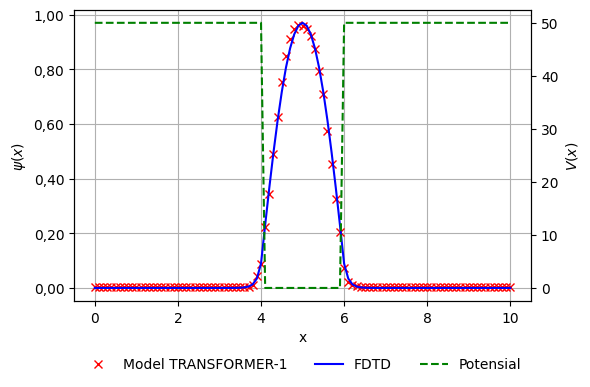

In [21]:
psi_fdtd  = psi_konvergen
psi_model = result[0,:].detach().cpu().numpy()

dx = 0.1
Nx = int(10 / dx)
x  = np.linspace(0, 10, Nx + 1)

v = np.zeros(Nx + 1)
for i in range(Nx + 1):
    v[i] = 50.0 if (i <= 40 or i >= 60) else 0.0

norm_model     = np.sqrt(np.sum(np.abs(psi_model)**2) * dx)
norm_fdtd      = np.sqrt(np.sum(np.abs(psi_fdtd)**2)  * dx)
psi_model_norm = psi_model / norm_model
psi_fdtd_norm  = psi_fdtd  / norm_fdtd

epsilon             = 0.1
error_rel_per_titik = np.abs(psi_fdtd_norm - psi_model_norm) / (np.abs(psi_fdtd_norm) + epsilon)
error_rel_max       = np.max(error_rel_per_titik)
print(f"Error relatif maksimum (per titik): {error_rel_max * 100:.2f}%")

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(x, psi_model_norm, 'x',label='Model TRANSFORMER-1', color='red')
ax1.plot(x, psi_fdtd_norm, label='FDTD',       color='blue')
ax1.set_xlabel('x')
ax1.set_ylabel(r'$\psi(x)$', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.yaxis.set_major_formatter(FuncFormatter(koma_formatter))
ax1.grid(True)

ax2 = ax1.twinx()
ax2.plot(x, v, label='Potensial', color='green', linestyle='--')
ax2.set_ylabel('$V(x)$', color='black')
ax2.tick_params(axis='y', labelcolor='black')

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2,
           loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
plt.tight_layout()
plt.savefig("perbandingan_fdtd_VS_model1.png", dpi=800)
plt.show()

/tmp/ipykernel_1425/3593943088.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


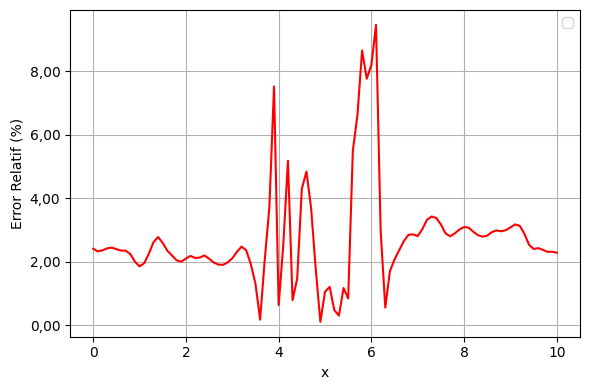

In [22]:
# ubahke bentuk persen
error_rel_percent = error_rel_per_titik * 100
# Plot
plt.figure(figsize=(6, 4))
plt.plot(x, error_rel_percent, color='red')
plt.xlabel("x")
plt.ylabel("Error Relatif (%)")
# plt.title("Error Relatif Per Titik: Model vs FDTD")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(FuncFormatter(koma_formatter))
plt.legend()
plt.tight_layout()
plt.savefig("error_relatif_pertitik.png", dpi=800)
plt.show()

In [25]:
def hitung_energi(psi, V, dx=0.1):
    Nx    = len(psi)
    d2psi = np.zeros(Nx)
    d2psi[1:-1] = (psi[:-2] - 2 * psi[1:-1] + psi[2:]) / dx**2
    H_psi = -0.5 * d2psi + V * psi
    return np.sum(psi * H_psi) * dx

def buat_potensial(Nx):
    v = np.zeros(Nx + 1)
    for i in range(Nx + 1):
        v[i] = 50.0 if (i <= 40 or i >= 60) else 0.0
    return v

def normalisasi_np(psi, dx=0.1):
    return psi / np.sqrt(np.sum(np.abs(psi)**2) * dx)


dx = 0.1
Nx = 100
x  = np.linspace(0, Nx * dx, Nx + 1)
V  = buat_potensial(Nx)

psi_fdtd  = psi_konvergen
psi_model = result[0,:].detach().cpu().numpy()
psi_model_norm = normalisasi_np(psi_model, dx)
psi_fdtd_norm  = normalisasi_np(psi_fdtd,  dx)

E_model = hitung_energi(psi_model_norm, V, dx)
E_fdtd  = hitung_energi(psi_fdtd_norm,  V, dx)

print("=" * 50)
print("PERBANDINGAN ENERGI KEADAAN DASAR")
print("=" * 50)
print(f"Energi Model Transformer1 : {E_model:.6f}")
print(f"Energi FDTD      : {E_fdtd:.6f}")
print(f"Error Relatif    : {abs(E_model - E_fdtd) / abs(E_fdtd) * 100:.2f}%")

PERBANDINGAN ENERGI KEADAAN DASAR
Energi Model Transformer1 : 1.117579
Energi FDTD      : 1.091932
Error Relatif    : 2.35%
